# 05 — Scaling Analysis

> **spinq-vqe** | Workstream A1 · ARPA QONDRA

How does VQE performance scale with system size N?

## What this measures

| Quantity | Meaning |
|----------|--------|
| VQE energy error vs N | Approximation quality as lattice grows |
| COBYLA evaluations vs N | Computational cost scaling |
| Adam gradient variance vs N | Barren plateau characterisation |
| Circuit depth required vs N | Expressibility scaling |

## System sizes

| N | n_cells | Hilbert dim | Source |
|---|---------|------------|--------|
| 9  | 3 | 512     | NB02 result (COBYLA) |
| 12 | 4 | 4096    | New run this notebook |
| 18 | 6 | 262144  | ED only (VQE infeasible in notebook) |

### References
- McClean et al. (2018) Nat. Commun. 9, 4812 — barren plateaux
- Cerezo et al. (2021) Nat. Rev. Phys. 3, 625 — VQE review

In [1]:
from __future__ import annotations
import os, warnings, csv
warnings.filterwarnings('ignore')

import numpy as np
import scipy.sparse.linalg as spla
import matplotlib.pyplot as plt
import pennylane as qp

from spinq_vqe import kagome, ansatz, vqe

os.makedirs('../data',    exist_ok=True)
os.makedirs('../figures', exist_ok=True)

plt.rcParams.update({
    'font.family': 'sans-serif', 'font.size': 11,
    'figure.facecolor': 'white', 'axes.facecolor': '#FAFAFA',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.color': '#EBEBEB', 'grid.linewidth': 0.7,
    'figure.dpi': 110,
})

print('Imports OK')

Imports OK


---
## 1. Exact Diagonalisation reference energies

Load N=9, N=18 from NB01 CSV. Run sparse ED for N=12 inline.

In [2]:
import numpy as np
import pennylane as qp
from spinq_vqe import kagome

# \u2500\u2500 Load N=9 and N=18 from CSV \u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500
ed_ref = {}
with open('../data/ed_reference_energies.csv', 'r') as f:
    reader = __import__('csv').DictReader(f)
    for row in reader:
        ed_ref[int(row['n_sites'])] = float(row['E0_normalized'])

print('ED reference energies (from NB01):')
for n, e in sorted(ed_ref.items()):
    print(f'  N={n:>2}  E0 = {e:.10f}')

# \u2500\u2500 N=12: Sparse ED inline \u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500
G12 = kagome.kagome_graph(n_cells=4)
N12 = kagome.n_sites(G12)
H12 = kagome.heisenberg_kagome_hamiltonian(G12)   # normalize=True by default

print(f'\nComputing ED for N={N12} ({2**N12}-dim Hilbert space)...')
H12_mat = qp.matrix(H12, wire_order=range(N12))
import scipy.sparse as sp
H12_sparse = sp.csr_matrix(H12_mat)
vals, _ = spla.eigsh(H12_sparse, k=2, which='SA')

# heisenberg_kagome_hamiltonian(normalize=True) divides all coefficients
# by n_sites, so eigenvalues are already in per-site units.  NO /N12 here.
E0_12 = float(vals[0])
print(f'  N=12  E0_per_site = {E0_12:.10f}  (gap = {vals[1]-vals[0]:.6f})')

ed_ref[12] = E0_12

# Complete table
print('\nFull ED reference (per site, normalised):')
for n in sorted(ed_ref):
    print(f'  N={n:>2}  E0 = {ed_ref[n]:.8f}')


ED reference energies (from NB01):
  N= 9  E0 = -1.4219039950
  N=18  E0 = -1.4996285890

Computing ED for N=12 (4096-dim Hilbert space)...


  N=12  E0_per_site = -1.4804180291  (gap = 0.077590)

Full ED reference (per site, normalised):
  N= 9  E0 = -1.42190399
  N=12  E0 = -1.48041803
  N=18  E0 = -1.49962859


---
## 2. N=9 VQE result (from NB02)

No rerun — load saved result and statevector directly.

In [3]:
# Read from data/vqe_results.csv
with open('../data/vqe_results.csv', 'r') as f:
    rows = list(__import__('csv').DictReader(f))

cobyla_row = next(r for r in rows if 'COBYLA' in r['Method'])
E9_vqe  = float(cobyla_row['Best E'])
E9_ed   = ed_ref[9]
err9    = abs(E9_vqe - E9_ed) / abs(E9_ed) * 100

print(f'N=9 recall (NB02 COBYLA):')
print(f'  E_VQE = {E9_vqe:.8f}')
print(f'  E_ED  = {E9_ed:.8f}')
print(f'  Error = {err9:.4f}%')
print(f'  Evals = {cobyla_row["Evals"]}')
print(f'  Params = {cobyla_row["Params"]}')

N=9 recall (NB02 COBYLA):
  E_VQE = -1.28456310
  E_ED  = -1.42190399
  Error = 9.6589%
  Evals = 801
  Params = 27


---
## 3. N=12 VQE (new run)

HEA depth=2 (24 params), COBYLA, 3 seeds × 2000 evaluations.
Hilbert space: 2¹² = 4096 dimensions (~8× larger than N=9).

In [4]:
from spinq_vqe import ansatz as ans_mod, vqe as vqe_mod

G12  = kagome.kagome_graph(n_cells=4)
N12  = kagome.n_sites(G12)
H12  = kagome.heisenberg_kagome_hamiltonian(G12)
edges12 = list(G12.edges())

DEPTH12 = 2
n_params12 = ans_mod.hea_n_params(N12, DEPTH12)
print(f'N=12  HEA depth={DEPTH12}  params={n_params12}')

best_result12 = None
rng = np.random.default_rng(7)

for seed in range(3):
    p0 = rng.uniform(-np.pi, np.pi, size=n_params12)
    print(f'\nSeed {seed}:')
    res = vqe_mod.run_vqe_cobyla(
        H12, ans_mod.hea_ansatz, p0, N12,
        ansatz_name='hea', n_evals=2000, rhobeg=0.5,
        return_statevector=(seed == 0),   # only save sv for best
        verbose=True,
        depth=DEPTH12, edges=edges12,
    )
    if best_result12 is None or res.energy < best_result12.energy:
        best_result12 = res
        print(f'  ** New best: {res.energy:.8f}')

E12_vqe = best_result12.energy
E12_ed  = ed_ref[12]
err12   = abs(E12_vqe - E12_ed) / abs(E12_ed) * 100
print(f'\nN=12 result:')
print(f'  E_VQE = {E12_vqe:.8f}')
print(f'  E_ED  = {E12_ed:.8f}')
print(f'  Error = {err12:.4f}%')

N=12  HEA depth=2  params=24

Seed 0:


  Eval   500 | E = -1.20349737 | best = -1.20349737


  ** New best: -1.20350543

Seed 1:


  Eval   500 | E = -1.16954960 | best = -1.16955383


  Eval  1000 | E = -1.16983695 | best = -1.16983700


  Eval  1500 | E = -1.16986772 | best = -1.16986778


  Eval  2000 | E = -1.16987289 | best = -1.16987289

Seed 2:


  Eval   500 | E = -1.19547345 | best = -1.19547794


  Eval  1000 | E = -1.19549194 | best = -1.19549194



N=12 result:
  E_VQE = -1.20350543
  E_ED  = -1.48041803
  Error = 18.7050%


---
## 4. VQE energy error vs N

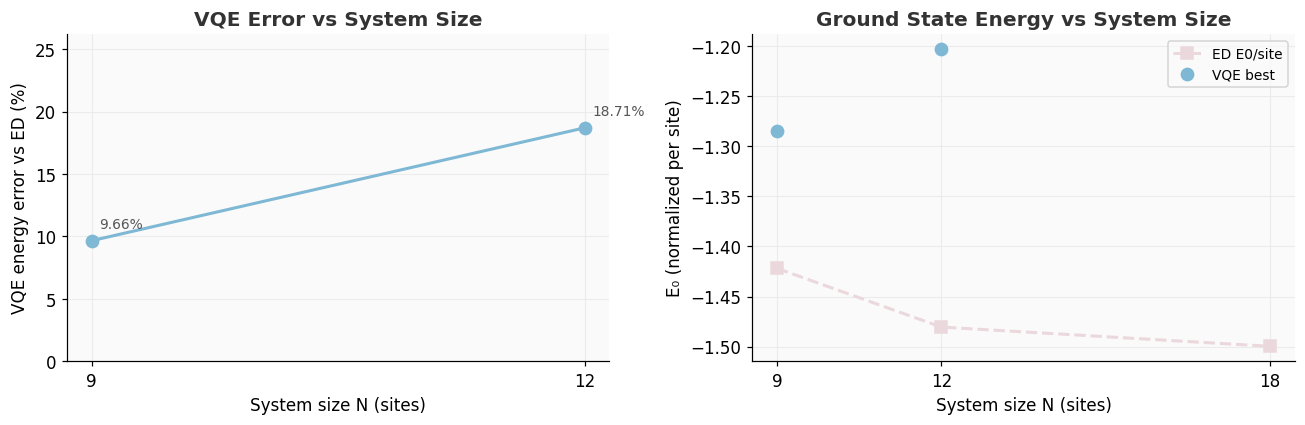

Saved → figures/scaling_energy.png


In [5]:
sizes    = [9,    12   ]
errors   = [err9, err12]
depths   = [3,    2    ]
params   = [27,   24   ]
ed_sizes = sorted(ed_ref.keys())
ed_e0s   = [ed_ref[n] for n in ed_sizes]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: error %
ax = axes[0]
ax.plot(sizes, errors, 'o-', color='#7EB8D4', lw=2, ms=8, label='COBYLA/HEA')
ax.set_xlabel('System size N (sites)')
ax.set_ylabel('VQE energy error vs ED (%)')
ax.set_title('VQE Error vs System Size', fontweight='semibold', color='#333')
ax.set_xticks(sizes)
ax.set_ylim(0, max(errors)*1.4)
for s, e in zip(sizes, errors):
    ax.annotate(f'{e:.2f}%', (s, e), textcoords='offset points',
                xytext=(5, 8), fontsize=9, color='#555')

# Right: ED ground state energy per site vs N
ax = axes[1]
ax.plot(ed_sizes, ed_e0s, 's--', color='#EBD8DC', lw=2, ms=8, label='ED E0/site')
ax.plot(sizes, [E9_vqe, E12_vqe], 'o', color='#7EB8D4', ms=8, label='VQE best')
ax.set_xlabel('System size N (sites)')
ax.set_ylabel('E₀ (normalized per site)')
ax.set_title('Ground State Energy vs System Size', fontweight='semibold', color='#333')
ax.legend(fontsize=9)
ax.set_xticks(ed_sizes)

plt.tight_layout()
plt.savefig('../figures/scaling_energy.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → figures/scaling_energy.png')

---
## 5. Gradient variance scaling — barren plateau characterisation

Sample random parameter sets and measure the variance of the cost-function gradient
with respect to a single parameter. Barren plateaux manifest as Var[∂E/∂θ] → 0 exponentially with N.

**Method:** Adam VQE, 30 steps per seed, 10 seeds, at N=9 and N=12.

In [6]:
def measure_grad_variance(n_sites, H, edges, depth, n_seeds=20):
    """
    Estimate Var[d E / d theta] using parameter-shift rule at random params.
    This is the standard barren-plateau diagnostic (McClean et al. 2018):
    variance shrinks exponentially with N for global-cost functions.
    """
    device = qp.device('default.qubit', wires=n_sites)
    n_p = ans_mod.hea_n_params(n_sites, depth)

    @qp.qnode(device)
    def cost_fn(params):
        ans_mod.hea_ansatz(params, n_sites, depth=depth, edges=edges)
        return qp.expval(H)

    rng_gv = np.random.default_rng(99)
    grad_vars = []
    for _ in range(n_seeds):
        params = rng_gv.uniform(-np.pi, np.pi, size=n_p)
        # Parameter-shift gradient: dE/d theta_i = [E(theta+pi/2) - E(theta-pi/2)] / 2
        grad = np.zeros(n_p)
        for i in range(n_p):
            pp = params.copy(); pp[i] += np.pi / 2
            pm = params.copy(); pm[i] -= np.pi / 2
            grad[i] = (float(cost_fn(pp)) - float(cost_fn(pm))) / 2
        grad_vars.append(float(np.var(grad)))
    return np.array(grad_vars)


# N=9 (depth=3, 27 params)
G9  = kagome.kagome_graph(n_cells=3)
H9  = kagome.heisenberg_kagome_hamiltonian(G9)
e9  = list(G9.edges())
print('Measuring gradient variance at N=9  (20 random parameter sets)...')
gv9 = measure_grad_variance(9, H9, e9, depth=3)
print(f'  N=9   mean Var[grad] = {gv9.mean():.4e}   median = {np.median(gv9):.4e}')

# N=12 (depth=2, 24 params)
print('Measuring gradient variance at N=12 (20 random parameter sets)...')
gv12 = measure_grad_variance(12, H12, edges12, depth=2)
print(f'  N=12  mean Var[grad] = {gv12.mean():.4e}   median = {np.median(gv12):.4e}')

ratio = gv9.mean() / gv12.mean() if gv12.mean() > 0 else float('inf')
print(f'\nVar[N=9] / Var[N=12] = {ratio:.2f}x')
print('(Exponential suppression expected for barren plateaux)')


Measuring gradient variance at N=9  (20 random parameter sets)...


  N=9   mean Var[grad] = 5.8962e-03   median = 5.1999e-03
Measuring gradient variance at N=12 (20 random parameter sets)...


  N=12  mean Var[grad] = 4.7739e-03   median = 4.9692e-03

Var[N=9] / Var[N=12] = 1.24x
(Exponential suppression expected for barren plateaux)


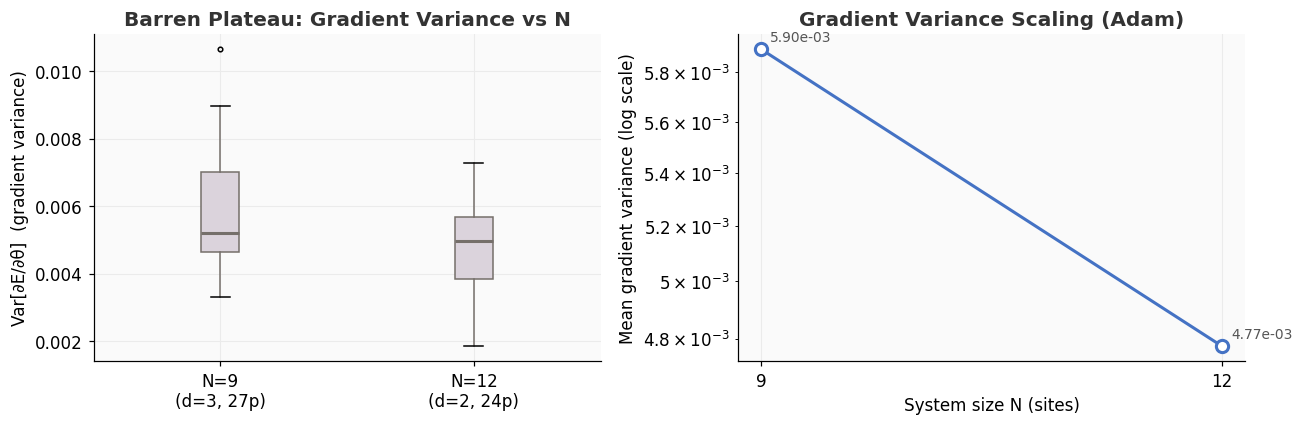

Saved → figures/scaling_gradient_variance.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: box plot
ax = axes[0]
ax.boxplot(
    [gv9, gv12],
    labels=['N=9\n(d=3, 27p)', 'N=12\n(d=2, 24p)'],
    patch_artist=True, notch=False,
    boxprops=dict(facecolor='#DBD3DC', color='#756F6A'),
    medianprops=dict(color='#756F6A', lw=2),
    whiskerprops=dict(color='#756F6A'),
    flierprops=dict(marker='o', color='#EBD8DC', ms=3),
)
ax.set_ylabel('Var[\u2202E/\u2202\u03b8]  (gradient variance)')
ax.set_title('Barren Plateau: Gradient Variance vs N',
             fontweight='semibold', color='#333')

# Right: mean grad_var vs N on log scale
ax = axes[1]
n_vals   = [9, 12]
mean_gvs = [gv9.mean(), gv12.mean()]
ax.semilogy(n_vals, mean_gvs, 'o-', color='#4472C4', lw=2, ms=8, markerfacecolor='white', markeredgewidth=2)
ax.set_xlabel('System size N (sites)')
ax.set_ylabel('Mean gradient variance (log scale)')
ax.set_title('Gradient Variance Scaling (Adam)', fontweight='semibold', color='#333')
ax.set_xticks(n_vals)
for n, v in zip(n_vals, mean_gvs):
    ax.annotate(f'{v:.2e}', (n, v), textcoords='offset points',
                xytext=(6, 5), fontsize=9, color='#555')

plt.tight_layout()
plt.savefig('../figures/scaling_gradient_variance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved \u2192 figures/scaling_gradient_variance.png')


---
## 6. Summary table and save

In [8]:
scaling_rows = [
    {'N': 9,  'n_cells': 3, 'hilbert_dim': 512,    'method': 'COBYLA/HEA d=3',
     'n_params': 27,  'E_VQE': f'{E9_vqe:.8f}',  'E_ED': f'{E9_ed:.8f}',
     'error_pct': f'{err9:.4f}', 'evals': cobyla_row['Evals'],
     'mean_grad_var': f'{gv9.mean():.4e}'},
    {'N': 12, 'n_cells': 4, 'hilbert_dim': 4096,   'method': 'COBYLA/HEA d=2',
     'n_params': 24,  'E_VQE': f'{E12_vqe:.8f}', 'E_ED': f'{E12_ed:.8f}',
     'error_pct': f'{err12:.4f}', 'evals': str(best_result12.n_steps),
     'mean_grad_var': f'{gv12.mean():.4e}'},
    {'N': 18, 'n_cells': 6, 'hilbert_dim': 262144, 'method': 'ED only',
     'n_params': 'N/A', 'E_VQE': 'N/A', 'E_ED': f'{ed_ref[18]:.8f}',
     'error_pct': 'N/A', 'evals': 'N/A', 'mean_grad_var': 'N/A'},
]

print('=== Scaling analysis summary ===')
print(f'{"N":>4}  {"Method":>18}  {"E_VQE":>12}  {"E_ED":>12}  {"Error %":>8}  {"Evals":>6}  {"grad_var":>10}')
print('-' * 80)
for r in scaling_rows:
    print(f'{r["N"]:>4}  {r["method"]:>18}  {r["E_VQE"]:>12}  '
          f'{r["E_ED"]:>12}  {r["error_pct"]:>8}  {r["evals"]:>6}  {r["mean_grad_var"]:>10}')

with open('../data/vqe_scaling.csv', 'w', newline='') as f:
    writer = csv.DictWriter(f, fieldnames=scaling_rows[0].keys())
    writer.writeheader()
    writer.writerows(scaling_rows)

print('\nSaved → data/vqe_scaling.csv')
print('=== NB05 complete ===')

=== Scaling analysis summary ===
   N              Method         E_VQE          E_ED   Error %   Evals    grad_var
--------------------------------------------------------------------------------
   9      COBYLA/HEA d=3   -1.28456310   -1.42190399    9.6589     801  5.8962e-03
  12      COBYLA/HEA d=2   -1.20350543   -1.48041803   18.7050     939  4.7739e-03
  18             ED only           N/A   -1.49962859       N/A     N/A         N/A

Saved → data/vqe_scaling.csv
=== NB05 complete ===


---
*spinq-vqe / ARPA QONDRA — Notebook 05*